# Fase 3 — Feature Engineering

**Input:** `data/processed/matches_clean.csv` (49 328 partidos, 1872–2026)  
**Output:**
- `data/processed/features_train.csv` — 15 504 partidos 2010–2025 con resultado conocido
- `data/processed/features_test.csv` — 72 partidos del Mundial 2026

**Decisiones de diseño:**
- Elo y FIFA rank: snapshots (may-2026 y sep-2025 respectivamente) usados como proxy estático.
- El feature engineering se aplica sobre el **dataset completo** (1872–2026) para que las features de forma de equipos en 2010 incluyan su historial pre-2010.
- Período de entrenamiento: 2010–2025 (fútbol moderno, equipos estables).
- Códigos de resultado: `H` = victoria local, `A` = victoria visitante, `D` = empate.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_features, FEATURE_COLS

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

print("Librerías cargadas.")

Librerías cargadas.


## 1. Carga de datos

In [2]:
df = pd.read_csv("../data/processed/matches_clean.csv")
df["date"] = pd.to_datetime(df["date"])

print(f"Filas totales : {len(df):,}")
print(f"Partidos jugados (score conocido) : {df['home_score'].notna().sum():,}")
print(f"Partidos futuros WC 2026         : {df['home_score'].isna().sum():,}")
print(f"\nRango de fechas : {df['date'].min().date()} → {df['date'].max().date()}")

Filas totales : 49,328
Partidos jugados (score conocido) : 49,256
Partidos futuros WC 2026         : 72

Rango de fechas : 1872-11-30 → 2026-06-27


## 2. Feature Engineering

Se aplica sobre el **dataset completo** para evitar lookback truncado en partidos de 2010.

In [3]:
%%time
df_feat = build_features(df)
print(f"Columnas generadas : {df_feat.shape[1]}")
print(f"Filas totales      : {df_feat.shape[0]:,}")

Columnas generadas : 54
Filas totales      : 49,328
CPU times: user 1.86 s, sys: 58.7 ms, total: 1.92 s
Wall time: 1.92 s


## 3. Selección de columnas y splits

In [4]:
# Verificar que todas las columnas esperadas están presentes
missing_cols = [c for c in FEATURE_COLS if c not in df_feat.columns]
if missing_cols:
    print(f"Columnas faltantes: {missing_cols}")
else:
    print("Todas las columnas esperadas presentes.")

feat_cols_available = [c for c in FEATURE_COLS if c in df_feat.columns]
df_final = df_feat[feat_cols_available + ["is_future"]].copy()

Todas las columnas esperadas presentes.


In [5]:
# Training: 2010-2025, score conocido
train_mask = (df_final["year"] >= 2010) & (df_final["year"] <= 2025) & ~df_final["is_future"]
# Test: 72 partidos WC 2026 (sin score)
test_mask = df_final["is_future"] & (df_final["year"] == 2026)

features_train = df_final[train_mask].drop(columns=["is_future"]).reset_index(drop=True)
features_test  = df_final[test_mask].drop(columns=["is_future", "result"]).reset_index(drop=True)

print(f"features_train : {features_train.shape}")
print(f"features_test  : {features_test.shape}")
print(f"\nDistribución target (train): H=local, A=visitante, D=empate")
print(features_train["result"].value_counts(normalize=True).round(3))

features_train : (15504, 42)
features_test  : (72, 41)

Distribución target (train): H=local, A=visitante, D=empate
result
H   0.478
A   0.290
D   0.232
Name: proportion, dtype: float64


## 4. Análisis de features

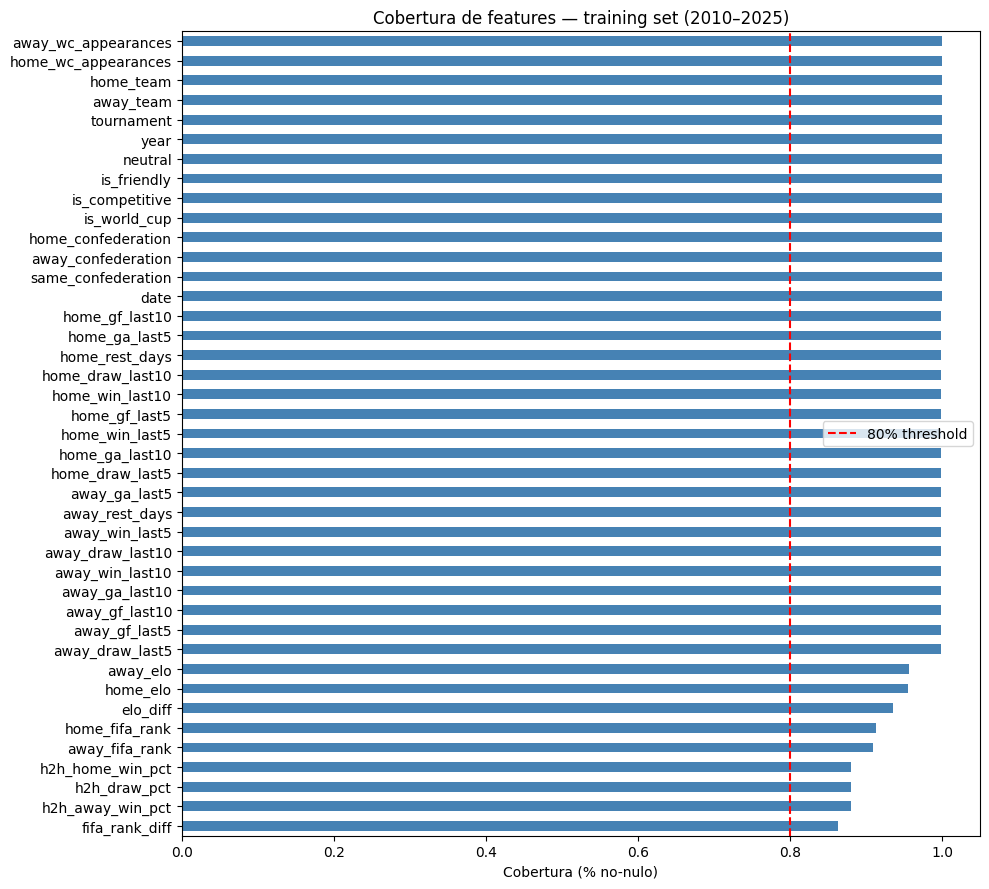

Guardado: reports/feature_coverage.png


In [6]:
# Cobertura (% no-nulo) por feature en el set de training
coverage = features_train.drop(columns=["result"]).notna().mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
coverage.plot.barh(ax=ax, color="steelblue")
ax.axvline(0.8, color="red", linestyle="--", label="80% threshold")
ax.set_xlabel("Cobertura (% no-nulo)")
ax.set_title("Cobertura de features — training set (2010–2025)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/feature_coverage.png", dpi=120)
plt.show()
print("Guardado: reports/feature_coverage.png")

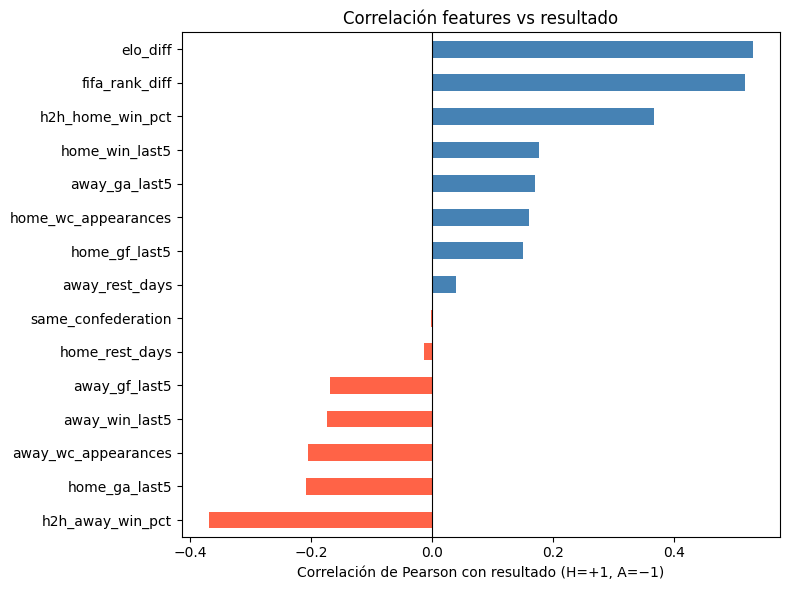

Guardado: reports/feature_correlation.png


In [7]:
# Correlación de features numéricas con el target
result_map = {"H": 1, "D": 0, "A": -1}
train_encoded = features_train.copy()
train_encoded["result_num"] = train_encoded["result"].map(result_map)

num_cols = [
    "elo_diff", "fifa_rank_diff",
    "home_gf_last5", "home_ga_last5", "home_win_last5",
    "away_gf_last5", "away_ga_last5", "away_win_last5",
    "h2h_home_win_pct", "h2h_away_win_pct",
    "home_rest_days", "away_rest_days",
    "home_wc_appearances", "away_wc_appearances",
    "same_confederation",
]

corr = (
    train_encoded[num_cols + ["result_num"]]
    .corr()["result_num"]
    .drop("result_num")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot.barh(ax=ax, color=["tomato" if v < 0 else "steelblue" for v in corr])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con resultado (H=+1, A=−1)")
ax.set_title("Correlación features vs resultado")
plt.tight_layout()
plt.savefig("../reports/feature_correlation.png", dpi=120)
plt.show()
print("Guardado: reports/feature_correlation.png")

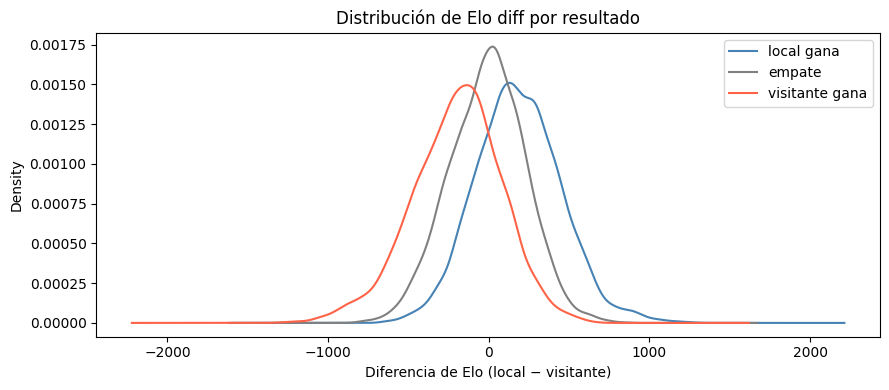

Guardado: reports/elo_diff_by_result.png


In [8]:
# Distribución de elo_diff por resultado
fig, ax = plt.subplots(figsize=(9, 4))
colors = {"H": "steelblue", "D": "gray", "A": "tomato"}
labels = {"H": "local gana", "D": "empate", "A": "visitante gana"}
for code, color in colors.items():
    subset = features_train[features_train["result"] == code]["elo_diff"].dropna()
    if len(subset) > 1:
        subset.plot.kde(ax=ax, label=labels[code], color=color)
ax.set_xlabel("Diferencia de Elo (local − visitante)")
ax.set_title("Distribución de Elo diff por resultado")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/elo_diff_by_result.png", dpi=120)
plt.show()
print("Guardado: reports/elo_diff_by_result.png")

In [9]:
# Resumen de nulls en features_train
null_pct = (features_train.isna().mean() * 100).round(1)
print("Nulls > 5% en training set:")
problematic = null_pct[null_pct > 5].sort_values(ascending=False)
if problematic.empty:
    print("  Ninguno — cobertura excelente.")
else:
    print(problematic.to_string())
print()
print("Nota: nulls esperados en fifa_rank_diff (solo disponible desde sep-2020)")
print("y h2h_* (primer enfrentamiento entre dos selecciones).")

Nulls > 5% en training set:
fifa_rank_diff     13.700
h2h_home_win_pct   12.000
h2h_draw_pct       12.000
h2h_away_win_pct   12.000
away_fifa_rank      9.100
home_fifa_rank      8.700
elo_diff            6.500

Nota: nulls esperados en fifa_rank_diff (solo disponible desde sep-2020)
y h2h_* (primer enfrentamiento entre dos selecciones).


In [10]:
# Estadísticas del test set (WC 2026)
key_feats = ["elo_diff", "fifa_rank_diff", "home_win_last10", "away_win_last10",
             "h2h_home_win_pct", "home_wc_appearances", "away_wc_appearances"]
print("Test set (WC 2026) — estadísticas clave:")
print(features_test[key_feats].describe().round(2).to_string())

Test set (WC 2026) — estadísticas clave:
       elo_diff  fifa_rank_diff  home_win_last10  away_win_last10  h2h_home_win_pct  home_wc_appearances  away_wc_appearances
count    66.000          66.000           72.000           72.000            44.000               72.000               72.000
mean     49.320           7.620            0.530            0.540             0.310                8.100                5.990
std     262.520          39.610            0.180            0.160             0.360                6.360                5.250
min    -464.000         -75.000            0.200            0.200             0.000                0.000                0.000
25%    -179.000         -24.750            0.400            0.400             0.000                2.750                1.750
50%      53.500           7.000            0.500            0.500             0.220                6.000                6.000
75%     254.500          40.750            0.700            0.700            

## 5. Guardar outputs

In [11]:
features_train.to_csv("../data/processed/features_train.csv", index=False)
features_test.to_csv("../data/processed/features_test.csv", index=False)

print(f"Guardado: data/processed/features_train.csv  → {features_train.shape}")
print(f"Guardado: data/processed/features_test.csv   → {features_test.shape}")
print(f"\nFeatures de entrenamiento ({len(features_train.columns)-1} features + target):")
feat_only = [c for c in features_train.columns if c != "result"]
for i, f in enumerate(feat_only, 1):
    print(f"  {i:2d}. {f}")

Guardado: data/processed/features_train.csv  → (15504, 42)
Guardado: data/processed/features_test.csv   → (72, 41)

Features de entrenamiento (41 features + target):
   1. date
   2. home_team
   3. away_team
   4. tournament
   5. year
   6. neutral
   7. is_friendly
   8. is_competitive
   9. is_world_cup
  10. home_confederation
  11. away_confederation
  12. same_confederation
  13. home_elo
  14. away_elo
  15. elo_diff
  16. home_fifa_rank
  17. away_fifa_rank
  18. fifa_rank_diff
  19. home_gf_last5
  20. home_ga_last5
  21. home_win_last5
  22. home_draw_last5
  23. away_gf_last5
  24. away_ga_last5
  25. away_win_last5
  26. away_draw_last5
  27. home_gf_last10
  28. home_ga_last10
  29. home_win_last10
  30. home_draw_last10
  31. away_gf_last10
  32. away_ga_last10
  33. away_win_last10
  34. away_draw_last10
  35. h2h_home_win_pct
  36. h2h_draw_pct
  37. h2h_away_win_pct
  38. home_rest_days
  39. away_rest_days
  40. home_wc_appearances
  41. away_wc_appearances
